In [1]:
import os, signal, sys, time

sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

import numpy as np

from utils import plotting

In [2]:
from rllib.env_wrapper import RLlibEnvWrapper


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-economist\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in

In [65]:
env_config_dict = {
    # Scenario with 2 planners
    "scenario_name": "custom/splitworld_overlay_regional",

        'components': [
        # (1) Building houses
        ('Build', {
            'skill_dist':                   'pareto', 
            'payment_max_skill_multiplier': 3,
            'build_labor':                  10,
            'payment':                      10
        }),
        # (2) Trading collectible resources
        ('ContinuousDoubleAuction', {
            'max_bid_ask':    10,
            'order_labor':    0.25,
            'max_num_orders': 5,
            'order_duration': 50
        }),
        # (3) Movement and resource collection
        ('Gather', {
            'move_labor':    1, #prev 1
            'collect_labor': 1,
            'skill_dist':    'pareto'
        }),
        # (4) Planner

        ("RegionalPeriodicBracketTax", {
            "region": "top",
            "planner_id": "p_top",
            "period": 100,
            "bracket_spacing": "us-federal",
            "usd_scaling": 1000,
            "disable_taxes": False,
            "tax_annealing_schedule": [-100, 0.001],
        }),
        ("RegionalPeriodicBracketTax", {
            "region": "bottom",
            "planner_id": "p_bottom",
            "period": 100,
            "bracket_spacing": "us-federal",
            "usd_scaling": 1000,
            "disable_taxes": False,
            "tax_annealing_schedule": [-100, 0.001],
        })

    ],
    

    # Map settings
    "env_layout_file": "map_100x50_water_gaps_3percent_resources.txt",
    "world_size": [100, 50],
    'episode_length': 1000, # Number of timesteps per episode

    'starting_agent_coin': 10,
    'fixed_four_skill_and_loc': False,

    # Agents and planners
    "n_agents": 4,
    "planner_subclasses": ["TopPlanner", "BottomPlanner"],
    #"planner_ids": ["p_top", "p_bottom"],
    #"planner_classes": ["TopPlanner", "BottomPlanner"],

    # Modes
    "multi_action_mode_planner": True,
    'multi_action_mode_agents': True,

    'flatten_observations': True,
    # When Flattening masks, concatenate each action subspace mask into a single array.
    # Note: flatten_masks = True is required for masking action logits in the code below.
    'flatten_masks': True,
    
    # How often to save the dense logs
    'dense_log_frequency': 1
}

In [4]:
env_obj = RLlibEnvWrapper({"env_config_dict": env_config_dict}, verbose=True)

[EnvWrapper] Spaces
[EnvWrapper] Obs (a)   
action_mask    : (55,)
flat           : (136,)
time           : (1,)
world-idx_map  : (2, 11, 11)
world-map      : (7, 11, 11)


[EnvWrapper] Obs (p)
  [p_top]
action_mask    : (308,)
flat           : (86,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 50, 50)
world-map      : (6, 50, 50)


  [p_bottom]
action_mask    : (308,)
flat           : (18,)
p0             : (8,)
p1             : (8,)
p2             : (8,)
p3             : (8,)
time           : (1,)
world-idx_map  : (2, 49, 50)
world-map      : (6, 49, 50)


[EnvWrapper] Action (a) MultiDiscrete([ 2 12 12 12 12  5])
[EnvWrapper] Action (p) {'p_top': MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22]), 'p_bottom': MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22])}


- both planners can see everything (no it is just include in num actions due to code structure)
- might changes this down the line 


# debug

In [5]:
flat = env_obj.env._generate_masks(flatten_masks=True)
print(flat["p_top"].shape)
print(flat["p_bottom"].shape)


(308,)
(308,)


In [6]:
# Get raw (unflattened) masks directly from env
raw_masks = env_obj.env._generate_masks(flatten_masks=False)

print("Keys for p_top:")
print(list(raw_masks["p_top"].keys()))
print("Num keys (p_top):", len(raw_masks["p_top"].keys()))
print("Per-key lengths (should be 22):", [len(v) for v in raw_masks["p_top"].values()])

print("\nKeys for p_bottom:")
print(list(raw_masks["p_bottom"].keys()))
print("Num keys (p_bottom):", len(raw_masks["p_bottom"].keys()))
print("Per-key lengths (should be 22):", [len(v) for v in raw_masks["p_bottom"].values()])

print("\nFlattened lengths (sanity):")
print("p_top:", sum(len(v) for v in raw_masks["p_top"].values()))
print("p_bottom:", sum(len(v) for v in raw_masks["p_bottom"].values()))




Keys for p_top:
['RegionalPeriodicBracketTax.TaxIndexBracket_000', 'RegionalPeriodicBracketTax.TaxIndexBracket_009', 'RegionalPeriodicBracketTax.TaxIndexBracket_039', 'RegionalPeriodicBracketTax.TaxIndexBracket_084', 'RegionalPeriodicBracketTax.TaxIndexBracket_160', 'RegionalPeriodicBracketTax.TaxIndexBracket_204', 'RegionalPeriodicBracketTax.TaxIndexBracket_510']
Num keys (p_top): 7
Per-key lengths (should be 22): [21, 21, 21, 21, 21, 21, 21]

Keys for p_bottom:
['RegionalPeriodicBracketTax.TaxIndexBracket_000', 'RegionalPeriodicBracketTax.TaxIndexBracket_009', 'RegionalPeriodicBracketTax.TaxIndexBracket_039', 'RegionalPeriodicBracketTax.TaxIndexBracket_084', 'RegionalPeriodicBracketTax.TaxIndexBracket_160', 'RegionalPeriodicBracketTax.TaxIndexBracket_204', 'RegionalPeriodicBracketTax.TaxIndexBracket_510']
Num keys (p_bottom): 7
Per-key lengths (should be 22): [21, 21, 21, 21, 21, 21, 21]

Flattened lengths (sanity):
p_top: 147
p_bottom: 147


In [7]:
# Raw (unflattened) masks
raw_masks = env_obj.env._generate_masks(flatten_masks=False)

print("Unflattened per-bracket lengths (p_top):", [len(v) for v in raw_masks["p_top"].values()])
print("Unflattened sum (p_top):", sum(len(v) for v in raw_masks["p_top"].values()))

# Flattened masks (what RLlib uses)
flat_masks = env_obj.env._generate_masks(flatten_masks=True)
print("Flattened mask length (p_top):", flat_masks["p_top"].shape)



Unflattened per-bracket lengths (p_top): [21, 21, 21, 21, 21, 21, 21]
Unflattened sum (p_top): 147
Flattened mask length (p_top): (308,)


In [8]:
# 1. Flattened
fm = env_obj.env._generate_masks(flatten_masks=True)["p_top"]
print("Flattened 7x22:\n", fm.reshape(-1, 22))

# 2. Raw
rm = env_obj.env._generate_masks(flatten_masks=False)["p_top"]
rm_matrix = np.vstack(list(rm.values()))
print("\nRaw 7x21:\n", rm_matrix)

# 3. Check split (if length 308)
if len(fm) == 308:
    print("\nTop-tax component:\n", fm[:154].reshape(7,22))
    print("\nBottom-tax component:\n", fm[154:].reshape(7,22))

Flattened 7x22:
 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

Raw 7x21:
 [[1 

In [9]:
for p in env_obj.env.world.planners:
    print("Planner ID:", repr(p.idx), "type:", type(p.idx))


Planner ID: 'p_top' type: <class 'str'>
Planner ID: 'p_bottom' type: <class 'str'>


In [10]:
import ai_economist
from ai_economist.foundation.components.redistribution import RegionalPeriodicBracketTax
#print(RegionalPeriodicBracketTax.__file__)
print(RegionalPeriodicBracketTax.get_n_actions)


<function RegionalPeriodicBracketTax.get_n_actions at 0x000002E0F6902AF8>


In [11]:
obs = env_obj.env.reset()
obs['p_top']['action_mask'].shape
obs['p_bottom']['action_mask'].shape

(308,)

## end debug

In [12]:
obs_space_p_top     = env_obj.observation_space_pl["p_top"]
act_space_p_top     = env_obj.action_space_pl["p_top"]

obs_space_p_bottom  = env_obj.observation_space_pl["p_bottom"]
act_space_p_bottom  = env_obj.action_space_pl["p_bottom"]


In [13]:
import ray
from ray.rllib.agents.ppo import PPOTrainer

In [14]:
# Policies
policies = {
    # Mobile agents (shared policy)
    "a": (
        None,
        env_obj.observation_space,   # dict-like space for any mobile agent (e.g., "0")
        env_obj.action_space,
        {}
    ),
    # Top planner
    "p_top": (
        None,
        env_obj.observation_space_pl["p_top"],
        env_obj.action_space_pl["p_top"],
        {}
    ),
    # Bottom planner
    "p_bottom": (
        None,
        env_obj.observation_space_pl["p_bottom"],
        env_obj.action_space_pl["p_bottom"],
        {}
    ),
}

# Mapping: digits -> "a"; exact planner ids -> their own policies
policy_mapping_fun = lambda i: (
    "a" if str(i).isdigit()
    else ("p_top" if i == "p_top" else ("p_bottom" if i == "p_bottom" else "a"))
)

policies_to_train = ["a", "p_top", "p_bottom"]



In [15]:
trainer_config = {
    "multiagent": {
        "policies": policies,
        "policies_to_train": policies_to_train,
        "policy_mapping_fn": policy_mapping_fun,
    }
}

trainer_config.update(
    {
        "num_workers": 0,
        "num_envs_per_worker": 1,
        # Other training parameters
        "train_batch_size":  4000,
        "sgd_minibatch_size": 4000,
        "num_sgd_iter": 1

    }
)

In [16]:
# We also add the "num_envs_per_worker" parameter for the env. wrapper to index the environments.
env_config = {
    "env_config_dict": env_config_dict,
    "num_envs_per_worker": trainer_config.get('num_envs_per_worker'),   
}

trainer_config.update(
    {
        "env_config": env_config        
    }
)

In [17]:
# from ray.rllib.agents.ppo import PPOTrainer
# import ray
# import os

# # Prevent Ray memory monitor crashes
# os.environ["RAY_DISABLE_MEMORY_MONITOR"] = "1"

# # Restart Ray cleanly
# ray.shutdown()
# ray.init(ignore_reinit_error=True)

# trainer_config = {

#     # Environment
#     "env_config": env_config_dict,

#     # ---- Stability fixes ----
#     "num_workers": 0,            # critical for Windows stability
#     "num_gpus": 0,

#     # ---- Framework ----
#     "framework": "tf",

#     # ---- PPO core parameters ----
#     "lr": 5e-5,
#     "gamma": 0.99,
#     "lambda": 0.95,
#     "clip_param": 0.2,

#     # ---- Training batch sizes ----
#     "rollout_fragment_length": 200,
#     "train_batch_size": 4000,
#     "sgd_minibatch_size": 512,
#     "num_sgd_iter": 10,

#     # ---- Model architecture ----
#     "model": {
#         "fcnet_hiddens": [256, 256],
#         "fcnet_activation": "tanh",
#     },

#     # ---- Logging / debugging ----
#     "log_level": "WARN",

# }

# trainer = PPOTrainer(
#     env=RLlibEnvWrapper,
#     config=trainer_config
# )

In [18]:
# NUM_ITERS = 200

# for iteration in range(NUM_ITERS):

#     result = trainer.train()

#     print(
#         f"Iter {iteration} | "
#         f"Reward: {result['episode_reward_mean']:.2f} | "
#         f"Episodes: {result['episodes_total']}"
#     )

In [19]:
# config = {
#     "env": RLlibEnvWrapper,
#     "env_config": {"env_config_dict": env_config_dict},
#     "num_envs_per_worker": trainer_config.get("num_envs_per_worker", 1),
# }

In [20]:
# import ray
# ray.shutdown()
# ray.init()

In [21]:
ray.init(webui_host="127.0.0.1")

2026-03-13 17:35:15,678	INFO resource_spec.py:212 -- Starting Ray with 3.66 GiB memory available for workers and up to 1.85 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).
2026-03-13 17:35:16,069	INFO services.py:1165 -- View the Ray dashboard at 127.0.0.1:8265


{'node_ip_address': '192.168.1.108',
 'raylet_ip_address': '192.168.1.108',
 'redis_address': '192.168.1.108:6379',
 'object_store_address': 'tcp://127.0.0.1:61134',
 'raylet_socket_name': 'tcp://127.0.0.1:60499',
 'webui_url': '127.0.0.1:8265',
 'session_dir': 'C:\\Users\\adria\\AppData\\Local\\Temp\\ray\\session_2026-03-13_17-35-15_673569_11896'}

In [22]:
trainer = PPOTrainer(
    env=RLlibEnvWrapper,
    config=trainer_config,
    )

2026-03-13 17:35:21,269	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-03-13 17:35:21,275	INFO trainer.py:585 -- Tip: set framework=tfe or the --eager flag to enable TensorFlow eager execution
2026-03-13 17:35:21,276	INFO trainer.py:612 -- Current log_level is WARN. For more information, set 'log_level': 'INFO' / 'DEBUG' or use the -v and -vv flags.
2026-03-13 17:36:18,103	INFO trainable.py:181 -- _setup took 56.832 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


In [23]:
NUM_ITERS = 10
for iteration in range(NUM_ITERS):
    print(f'********** Iter : {iteration} **********')
    result = trainer.train()
    print(f'''episode_reward_mean: {result.get('episode_reward_mean')}''')

********** Iter : 0 **********
episode_reward_mean: -387.05570428468195
********** Iter : 1 **********
episode_reward_mean: -371.3440696943224
********** Iter : 2 **********
episode_reward_mean: -359.676065877363
********** Iter : 3 **********
episode_reward_mean: -364.8663913354089
********** Iter : 4 **********
episode_reward_mean: -378.71947321479854
********** Iter : 5 **********
episode_reward_mean: -368.90384256173724
********** Iter : 6 **********
episode_reward_mean: -357.49473510535944
********** Iter : 7 **********
episode_reward_mean: -357.0492598468096
********** Iter : 8 **********
episode_reward_mean: -360.52313279575526
********** Iter : 9 **********
episode_reward_mean: -362.3821527558932


In [24]:
# def generate_rollout_from_current_trainer_policy(
#     trainer, 
#     env_obj,
#     num_dense_logs=1
# ):
#     dense_logs = {}
#     for idx in range(num_dense_logs):
#         # Set initial states
#         agent_states = {}
#         for agent_idx in range(env_obj.env.n_agents):
#             agent_states[str(agent_idx)] = trainer.get_policy("a").get_initial_state()
#         planner_states = trainer.get_policy("p").get_initial_state()   

#         # Play out the episode
#         steps = 0
#         obs = env_obj.reset(force_dense_logging=True)
#         for t in range(env_obj.env.episode_length):
#             actions = {}
#             for agent_idx in range(env_obj.env.n_agents):
#                 # Use the trainer object directly to sample actions for each agent
#                 actions[str(agent_idx)] = trainer.compute_action(
#                     obs[str(agent_idx)], 
#                     agent_states[str(agent_idx)], 
#                     policy_id="a",
#                     full_fetch=False
#                 )
            
#             # Action sampling for the planner
#             actions["p"] = trainer.compute_action(
#                 obs['p'], 
#                 planner_states, 
#                 policy_id='p',
#                 full_fetch=False
#             )
#             steps += 1
#             obs, rew, done, info = env_obj.step(actions)        
#             if done['__all__']:
#                 break

#         #print("Episode length:", steps)
#         import copy
#         dense_logs[idx] = copy.deepcopy(env_obj.env.dense_log) #new

        




#     return dense_logs

In [25]:
# dense_logs = generate_rollout_from_current_trainer_policy(
#     trainer, 
#     env_obj,
#     num_dense_logs=10
# )

In [26]:
# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10
# ):
#     dense_logs = {}

#     for idx in range(num_dense_logs):
#         # Reset RNN states
#         agent_states = {
#             str(agent_idx): trainer.get_policy("a").get_initial_state()
#             for agent_idx in range(env_obj.env.n_agents)
#         }
#         planner_states = trainer.get_policy("p").get_initial_state()


#         obs = env_obj.reset(force_dense_logging=True)

#         planner_actions_log = []

#         for t in range(env_obj.env.episode_length):

#             # Collect agent actions
#             actions = {}
#             for agent_idx in range(env_obj.env.n_agents):
#                 act = trainer.compute_action(
#                     obs[str(agent_idx)],
#                     agent_states[str(agent_idx)],
#                     policy_id="a",
#                     full_fetch=False
#                 )
#                 actions[str(agent_idx)] = act

#             # Collect the planner action
#             p_act = trainer.compute_action(
#                 obs["p"],
#                 planner_states,
#                 policy_id="p",
#                 full_fetch=False
#             )
#             actions["p"] = p_act

#             planner_actions_log.append(p_act)

#             obs, rew, done, info = env_obj.step(actions)
#             if done["__all__"]:
#                 break

#         # Copy Foundation's dense log and extend with planner actions
#         dense_logs[idx] = dict(env_obj.env.dense_log)
#         dense_logs[idx]["planner_actions"] = np.array(planner_actions_log)

#     return dense_logs

In [27]:
# dense_logs = generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10
# )

In [28]:
def generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
):
    dense_logs = {}

    for idx in range(num_dense_logs):

        # --- Reset RNN / internal policy states ---
        agent_states = {
            str(agent_idx): trainer.get_policy("a").get_initial_state()
            for agent_idx in range(env_obj.env.n_agents)
        }

        p_top_states = trainer.get_policy("p_top").get_initial_state()
        p_bottom_states = trainer.get_policy("p_bottom").get_initial_state()

        # --- Reset env (enable dense logging) ---
        obs = env_obj.reset(force_dense_logging=True)

        planner_actions_log = {"p_top": [], "p_bottom": []}

        for t in range(env_obj.env.episode_length):

            actions = {}

            # --- Agent actions ---
            for agent_idx in range(env_obj.env.n_agents):
                act = trainer.compute_action(
                    obs[str(agent_idx)],
                    agent_states[str(agent_idx)],
                    policy_id="a",
                    full_fetch=False
                )
                actions[str(agent_idx)] = act

            # --- Planner p_top ---
            act_top = trainer.compute_action(
                obs["p_top"],
                p_top_states,
                policy_id="p_top",
                full_fetch=False
            )
            actions["p_top"] = act_top
            planner_actions_log["p_top"].append(act_top)

            # --- Planner p_bottom ---
            act_bottom = trainer.compute_action(
                obs["p_bottom"],
                p_bottom_states,
                policy_id="p_bottom",
                full_fetch=False
            )
            actions["p_bottom"] = act_bottom
            planner_actions_log["p_bottom"].append(act_bottom)

            # --- Step environment ---
            obs, rew, done, info = env_obj.step(actions)
            if done["__all__"]:
                break

        # Store dense logs + planner action traces
        dense_logs[idx] = dict(env_obj.env.dense_log)
        dense_logs[idx]["planner_actions"] = planner_actions_log

    return dense_logs

In [29]:
dense_logs = generate_rollout_with_planner_actions(
    trainer,
    env_obj,
    num_dense_logs=10
)

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   9.50 (n=  6) |   9.00 (n=  7) |   9.00 (n=  5) |  10.00 (n=  3)
Cost (Stone)   :   8.89 (n=  9) |   7.92 (n= 13) |   8.50 (n=  4) |   8.25 (n=  8)

Income (Wood)  :   9.50 (n=  6) |   9.50 (n=  8) |   7.00 (n=  1) |   9.17 (n=  6)
Income (Stone) :   6.88 (n=  8) |   8.40 (n=  5) |   9.67 (n= 12) |   7.78 (n=  9)
Income (Build) :  16.46 (n= 16) |  22.23 (n= 14) |  11.33 (n=  4) |  13.27 (n=  4)


{'p_top': [array([ 4, 15, 14, 21,  6,  7, 21, 12,  9, 17,  8,  2,  2, 12],
        dtype=int64),
  array([14,  7, 12, 15, 11,  9,  9, 15,  8,  4,  4, 15, 11,  9],
        dtype=int64),
  array([ 8, 14,  5,  5, 13,  8,  6,  9,  0, 14, 13,  0,  4, 13],
        dtype=int64),
  array([ 6, 15,  4,  8, 12, 11, 12, 16, 15, 15,  0, 11, 13, 10],
        dtype=int64),
  array([ 9, 14, 15,  9,  1, 11,  6,  9, 13, 21, 14,  6,  3, 12],
        dtype=int64),
  array([ 0, 21,  1,  5,  8, 14, 15,  2,  5, 16, 21,  0,  7, 14],
        dtype=int64),
  array([16, 18, 17, 17, 20,  6,  1,  6, 18,  2,  3,  4, 20, 14],
        dtype=int64),
  array([17, 21,  0, 14,  0,  9, 10,  3, 17,  5, 17,  8, 21, 19],
        dtype=int64),
  array([12, 11, 13, 13,  8, 13, 17,  8,  2, 12, 14, 14, 15,  6],
        dtype=int64),
  array([10, 10, 17, 13,  2,  0, 16, 19, 13, 19, 20,  8,  7,  9],
        dtype=int64),
  array([ 1, 11,  2, 16,  8, 19,  0, 14, 11,  6,  2,  0, 13,  6],
        dtype=int64),
  array([21,  0, 16,  8

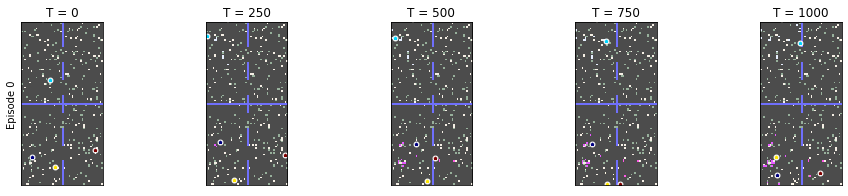

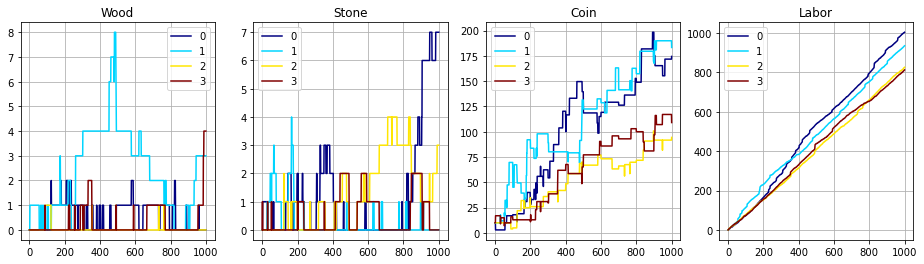

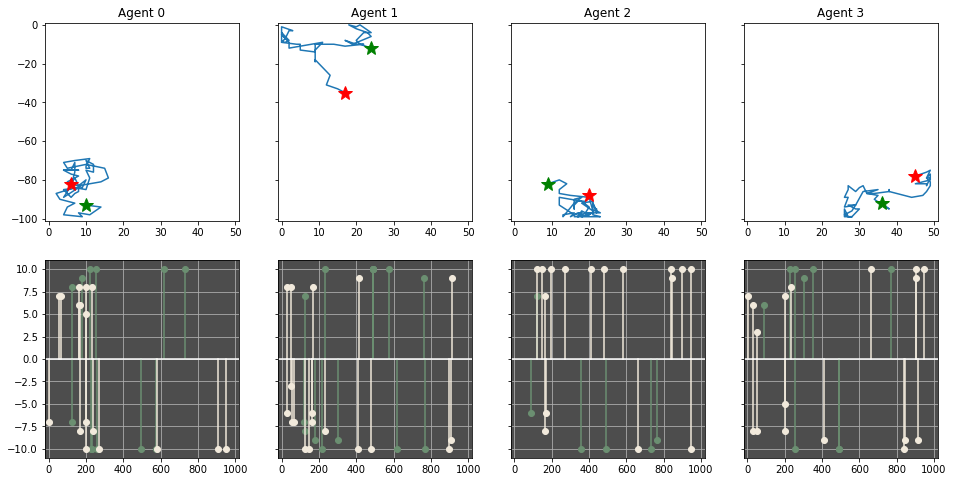

In [30]:
plotting.breakdown(dense_logs[0])   # agent actions (unchanged)
dense_logs[0]["planner_actions"]    # <-- your new planner actions

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 ____
Cost (Wood)    :   8.67 (n=  9) |   9.75 (n=  4) |   7.56 (n=  9) |   8.11 (n=  9)
Cost (Stone)   :   8.62 (n=  8) |   9.25 (n=  4) |   7.31 (n= 16) |   7.11 (n=  9)

Income (Wood)  :   8.78 (n=  9) |   8.00 (n=  6) |   9.00 (n=  8) |   7.38 (n=  8)
Income (Stone) :   7.86 (n=  7) |   8.75 (n=  4) |   7.38 (n= 13) |   7.77 (n= 13)
Income (Build) :  16.46 (n= 14) |  11.33 (n=  9) |  22.23 (n= 11) |  13.27 (n= 10)


{'p_top': [array([ 3,  4, 15, 20,  6, 13,  0,  8, 13,  5,  0, 17, 16,  4],
        dtype=int64),
  array([11,  2,  1,  2,  8,  8,  8, 20,  0,  8,  3,  2,  7, 19],
        dtype=int64),
  array([ 0,  3, 11, 19,  5, 19, 18, 21, 10,  8,  1,  7, 12, 10],
        dtype=int64),
  array([ 5,  8, 14,  4, 12,  4, 12, 11,  5, 12, 21,  4, 20, 16],
        dtype=int64),
  array([ 7,  5, 17, 20,  7,  1,  1,  0,  4,  6, 15, 21, 19,  6],
        dtype=int64),
  array([17, 13,  7, 21,  9, 11, 19, 17,  0, 11,  1,  7,  4,  6],
        dtype=int64),
  array([ 4,  1, 20, 16, 10, 16,  4,  2,  0, 18, 19,  5, 10, 14],
        dtype=int64),
  array([ 9, 21,  7, 14, 18,  3,  4,  6, 15, 16, 12,  2,  4, 12],
        dtype=int64),
  array([ 9, 17,  4,  2,  0, 11,  6, 16,  4, 21, 12, 11,  7, 15],
        dtype=int64),
  array([ 4, 12,  8, 17,  5,  7,  2,  5, 10, 10, 20,  4, 10,  4],
        dtype=int64),
  array([21, 16, 21, 19, 20, 17,  2, 15,  9, 11, 14, 17,  9, 19],
        dtype=int64),
  array([18, 11, 14,  1

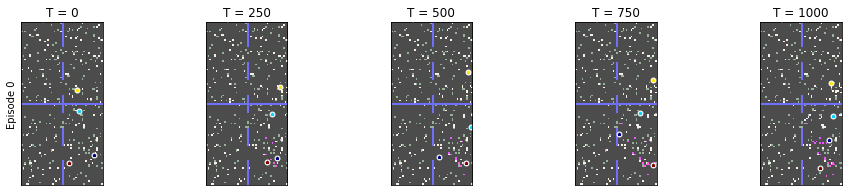

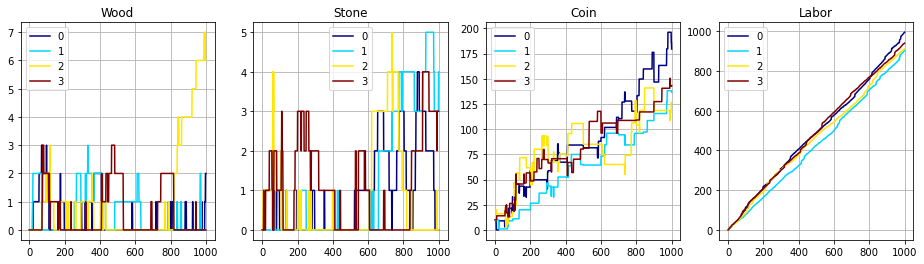

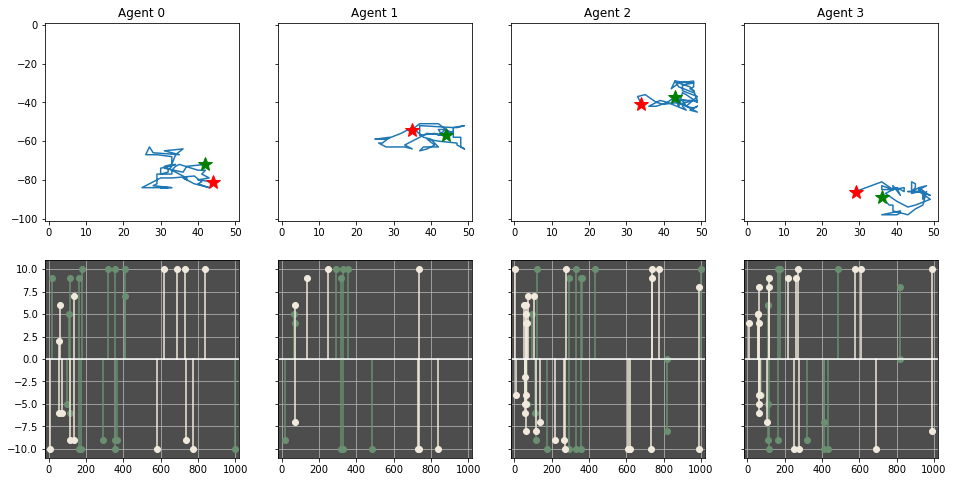

2026-03-15 12:36:09,331	ERROR worker.py:949 -- print_logs: Connection closed by server.
2026-03-15 12:36:09,351	ERROR import_thread.py:93 -- ImportThread: Connection closed by server.
2026-03-15 12:36:09,351	ERROR worker.py:1049 -- listen_error_messages_raylet: Connection closed by server.


In [ ]:
plotting.breakdown(dense_logs[9])   # agent actions (unchanged)
dense_logs[9]["planner_actions"]    # <-- your new planner actions

In [32]:
import pprint
pprint.pprint(dense_logs[0]["planner_actions"])


{'p_bottom': [array([14, 14,  4,  3, 19, 17, 13, 18, 15, 19, 17, 20,  3,  1],
      dtype=int64),
              array([10, 17, 10, 16, 14, 20, 10,  0, 19, 15,  5,  3,  4,  1],
      dtype=int64),
              array([10,  3,  6, 14,  1,  6, 19, 19,  0,  1, 14,  1,  9, 13],
      dtype=int64),
              array([17, 15,  9, 10,  5, 19,  9,  2,  0,  3,  1,  9, 16,  4],
      dtype=int64),
              array([ 9, 10, 16,  2,  2, 20, 16, 16, 14, 11,  2, 18,  4,  8],
      dtype=int64),
              array([20,  8,  7, 12,  9,  7, 19, 13,  7,  6,  2,  7,  4, 16],
      dtype=int64),
              array([10, 12, 13, 16, 14, 16,  8, 15,  0,  2,  7, 10, 17,  4],
      dtype=int64),
              array([12, 10, 17,  3, 16, 11,  5,  2, 18, 18, 20,  1, 18,  5],
      dtype=int64),
              array([ 5,  5,  7, 13, 21,  9,  2, 21, 17, 11,  4, 13,  1, 21],
      dtype=int64),
              array([ 2, 21,  3,  6,  6, 20, 11, 15,  9,  7, 11,  9, 20, 15],
      dtype=int64),
              array(

In [33]:
print("Top planner action space:", env_obj.action_space_pl["p_top"])
print("Bottom planner action space:", env_obj.action_space_pl["p_bottom"])


Top planner action space: MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22])
Bottom planner action space: MultiDiscrete([22 22 22 22 22 22 22 22 22 22 22 22 22 22])


In [34]:
print("p_top nvec:", env_obj.action_space_pl["p_top"].nvec)
print("p_bottom nvec:", env_obj.action_space_pl["p_bottom"].nvec)

p_top nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]
p_bottom nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]


In [35]:
for comp in env_obj.env.components:
    if "BracketTax" in comp.name:
        print(comp.period, comp.tax_cycle_pos)


100 1
100 1


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def _get_disc_rates_from_env(env_obj):
#     """
#     Try to read the (planner) discrete tax rate grid from the first tax component
#     so we can label y-axis with actual rates (0..1). Fallback to indices if missing.
#     """
#     disc = None
#     try:
#         for comp in env_obj.env.components:
#             if "BracketTax" in comp.name:
#                 # Most forks expose .disc_rates (length ~ 21/22)
#                 if hasattr(comp, "disc_rates") and comp.disc_rates is not None:
#                     disc = np.array(comp.disc_rates, dtype=float)
#                     break
#     except Exception:
#         pass
#     return disc  # may be None


# def plot_planner_tax_lines(
#     dense_log,
#     env_obj,
#     planner_actions_key="planner_actions",
#     period=100,
#     top_first=True,
#     episode_len=None,
#     title="Planner tax choices per bracket (top vs bottom)",
#     figsize=(16, 10)
# ):
#     """
#     Line plot per bracket (7 subplots in a column).
#     Shows chosen tax *indices* for p_top's top-7 and p_bottom's bottom-7 at each decision step.
#     Assumes each action vector has length 14 (7 top + 7 bottom); if not, will adapt.

#     Args:
#         dense_log: a single episode's dense_log dict (e.g., dense_logs[0]).
#         env_obj: the running env wrapper (to fetch disc_rates and confirm period).
#         planner_actions_key: key in dense_log where planner actions were logged.
#         period: tax period (planners act once every `period` timesteps).
#         top_first: if True, split action vector as [top7 | bottom7], else [bottom7 | top7].
#         episode_len: override episode length if needed; otherwise infer from log length.
#         title: figure title.
#         figsize: matplotlib figure size.
#     """
    
#     # 1) Pull (possibly large) planner action arrays
#     pa = dense_log.get(planner_actions_key, None)
#     if pa is None:
#         raise KeyError(f"'{planner_actions_key}' not found in dense_log.")
#     if not isinstance(pa, dict) or "p_top" not in pa or "p_bottom" not in pa:
#         raise ValueError(f"'{planner_actions_key}' must be a dict with keys 'p_top' and 'p_bottom'.")

#     # Convert lists to arrays: shape (T, 14)
#     p_top_actions    = np.asarray(pa["p_top"])    # (T, 14) or (T, 7) depending on setup
#     p_bottom_actions = np.asarray(pa["p_bottom"]) # (T, 14) or (T, 7)

#     if episode_len is None:
#         episode_len = len(p_top_actions)

#     # 2) Build decision time indices (0-based)
#     # With tax_cycle_pos starting at 1, planners act at logical timesteps 1, 101, 201,...
#     # Those correspond to *indices* 0, 100, 200, ...
#     decision_idxs = np.arange(0, episode_len, period, dtype=int)
#     decision_idxs = decision_idxs[decision_idxs < episode_len]

#     # 3) Extract decisions as arrays shape (num_decisions, num_subspaces)
#     A_top    = p_top_actions[decision_idxs]    # (D, S)
#     A_bottom = p_bottom_actions[decision_idxs] # (D, S)

#     # 4) Determine how to split the subspaces into (7 top + 7 bottom)
#     # If action space has 14 subspaces, we split in half:
#     S = A_top.shape[1]
#     if S % 2 != 0:
#         print(f"[WARN] Expected even number of subspaces; got {S}. Plotting all as-is.")
#         half = S // 2  # leave some subspaces unused
#     else:
#         half = S // 2

#     # Slices for top/bottom half in the flattened vector
#     if top_first:
#         sl_top    = slice(0, half)
#         sl_bottom = slice(half, S)
#     else:
#         sl_top    = slice(half, S)
#         sl_bottom = slice(0, half)

#     # Now split into 7-by-time arrays
#     # shape after transpose: (7, D)
#     if half == 0:
#         raise ValueError("No subspaces found to plot.")

#     top_brackets_over_time    = A_top[:, sl_top].T       # (7, D)
#     bottom_brackets_over_time = A_bottom[:, sl_bottom].T # (7, D)

#     # 5) Try to fetch disc_rates to label y-axis in human-friendly terms
#     disc_rates = _get_disc_rates_from_env(env_obj)
#     # Each subspace has 'n_choices' choices (22 in your setup).
#     # Using the first planner's action space nvec to set y-limit sanity.
#     try:
#         nvec = env_obj.action_space_pl["p_top"].nvec
#         n_choices = int(nvec[0])
#     except Exception:
#         # fallback if we cannot read nvec
#         n_choices = int(top_brackets_over_time.max() + 1)

#     # 6) Plot: 7 rows, 1 column, each row shows p_top (solid) and p_bottom (dashed)
#     fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
#     fig.suptitle(title)

#     # X positions are decision timesteps (1-based for nice labeling)
#     x_t = (decision_idxs + 1).astype(int)

#     for b in range(min(7, top_brackets_over_time.shape[0], bottom_brackets_over_time.shape[0])):
#         ax = axes[b]
#         y_top = top_brackets_over_time[b]
#         y_bot = bottom_brackets_over_time[b]

#         ax.plot(x_t, y_top, label="p_top", color="#1f77b4", lw=2)
#         ax.plot(x_t, y_bot, label="p_bottom", color="#ff7f0e", lw=2, ls="--")

#         ax.set_ylabel(f"Bracket {b}")
#         #ax.set_ylabel(f"{self.regional_brackets[b]:.2f}k USD bracket")
#         ax.grid(True, alpha=0.3)

#         # Y ticks: either raw indices or mapped to rates if we have them
#         if disc_rates is not None and len(disc_rates) == n_choices:
#             # Show fewer ticks for clarity (e.g., 0, 5, 10, 15, 21)
#             major_idx = np.linspace(0, n_choices - 1, num=min(6, n_choices), dtype=int)
#             ax.set_yticks(major_idx)
#             # Convert rates to percentages where possible
#             try:
#                 ax.set_yticklabels([f"{100*disc_rates[i]:.0f}%" for i in major_idx])
#             except Exception:
#                 ax.set_yticklabels([str(int(i)) for i in major_idx])
#             ax.set_ylim([-0.5, n_choices - 0.5])
#         else:
#             ax.set_ylim([-0.5, n_choices - 0.5])

#         if b == 0:
#             ax.legend(loc="upper right")

#     axes[-1].set_xlabel("Timestep")
#     plt.tight_layout()
#     plt.show()
#     return fig

# # Pick episode 0; period is 100; top component first in the 14-vector
# fig = plot_planner_tax_lines(
#     dense_logs[0],
#     env_obj,
#     period=100,
#     top_first=True,   # set to False if your action vector is [bottom7 | top7]
#     title="Regional planners: chosen tax indices per bracket"
# )

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def plot_planner_tax_lines_percent(
    dense_log,
    brackets,
    period=100,
    top_first=True,
    title="Planner tax choices over time (percent)",
    figsize=(14, 10)
):
    """
    Plots 7 rows of time-series marginal tax rates (0–1) chosen by p_top and p_bottom.

    Parameters:
        dense_log  : a single episode's dense_log (e.g., dense_logs[0])
        brackets   : numpy array of 7 bracket cutoffs
        period     : planning period (100)
        top_first  : True if action vector = [top7 | bottom7]
    """

    pa = dense_log["planner_actions"]

    # Extract decision arrays for each planner
    A_top    = np.array(pa["p_top"])    # shape (T, 14)
    A_bottom = np.array(pa["p_bottom"]) # shape (T, 14)

    T, S = A_top.shape
    assert S == 14, f"Expected 14 subspaces, got {S}"

    # Decision times (0,100,200,...)
    decision_idxs = np.arange(0, T, period)
    decision_idxs = decision_idxs[decision_idxs < T]

    # Get decisions
    A_top_decisions    = A_top[decision_idxs]
    A_bottom_decisions = A_bottom[decision_idxs]

    # Split into 7+7
    half = S // 2
    if top_first:
        top7    = A_top_decisions[:,    :half]
        bottom7 = A_bottom_decisions[:, half:]
    else:
        top7    = A_top_decisions[:, half:]
        bottom7 = A_bottom_decisions[:, :half]

    # Transpose for bracket-major
    top7    = top7.T       # (7, D)
    bottom7 = bottom7.T    # (7, D)

    # Map action index → percent (0–1)
    rate_levels = np.linspace(0, 1, 22)

    top_rates    = rate_levels[np.clip(top7 - 1, 0, 21)]
    bottom_rates = rate_levels[np.clip(bottom7 - 1, 0, 21)]

    # X axis = decision timesteps (1-based)
    X = (decision_idxs + 1)

    # Plot 7 rows
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    for b in range(7):
        ax = axes[b]
        ax.plot(X, top_rates[b],    label="p_top",    lw=2, color="#1f77b4")
        ax.plot(X, bottom_rates[b], label="p_bottom", lw=2, color="#ff7f0e", ls="--")

        # Optional: label each subplot with the bracket start
        ax.set_ylabel(f"{brackets[b]:.2f}k")

        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        if b == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Timestep")
    plt.tight_layout()
    plt.show()

    return fig

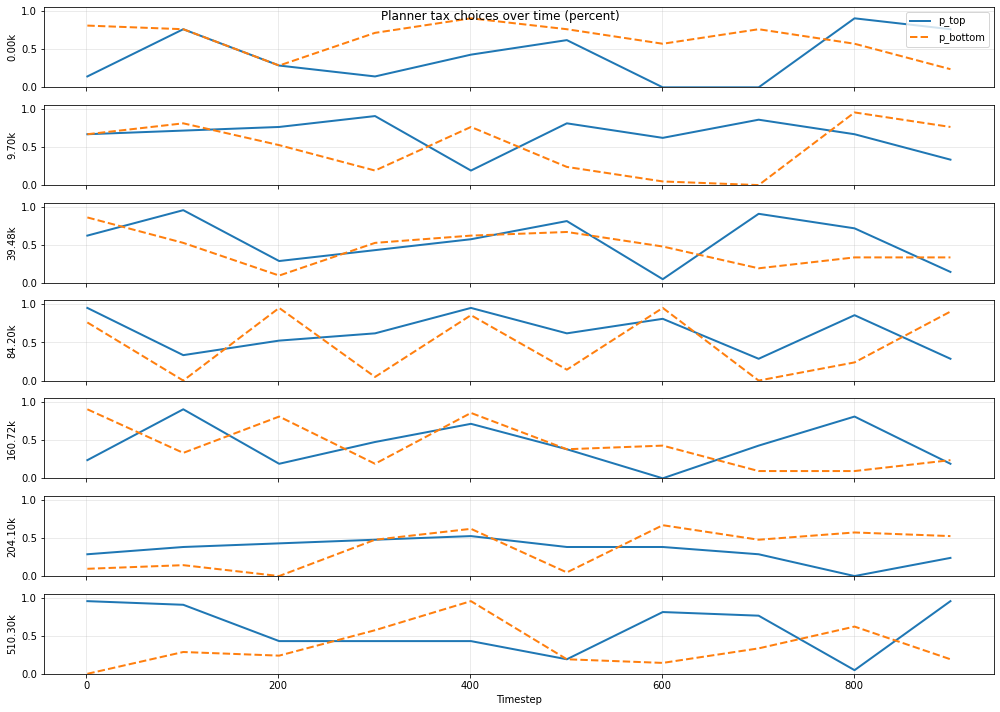

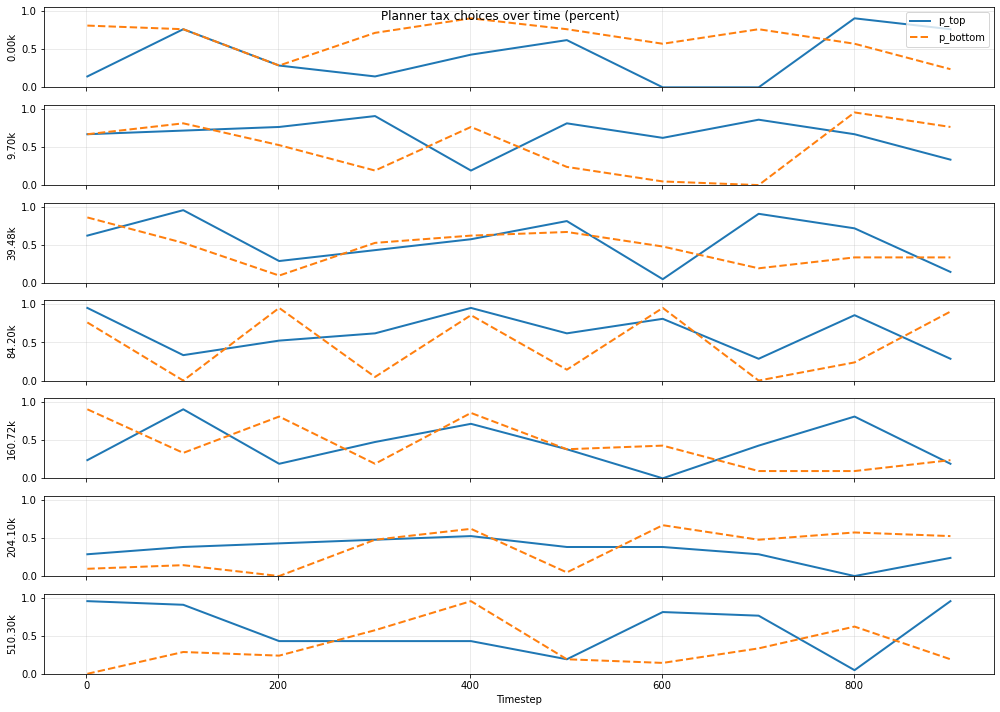

In [62]:
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / 1000   # convert to k USD

plot_planner_tax_lines_percent(
    dense_logs[0],
    brackets=brackets,
    period=100,
    top_first=True
)

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def plot_final_tax_schedules_two_planners(dense_log, top_first=True):
    """
    Plots the final marginal tax schedule for both planners (p_top and p_bottom),
    stacked vertically in two subplots.

    Arguments:
        dense_log: One episode's dense log, e.g. dense_logs[0]
        top_first: If True, planner action vector is [top7 | bottom7],
                   otherwise [bottom7 | top7].
    """

    planner_actions = dense_log["planner_actions"]

    # Extract final chosen action vector for each planner
    final_top    = np.array(planner_actions["p_top"][-1])     # (14,)
    final_bottom = np.array(planner_actions["p_bottom"][-1])  # (14,)
    

    # Split into 7+7
    S = final_top.shape[0]
    if S != 14:
        raise ValueError(f"Expected 14 subspaces (7 top + 7 bottom), got {S}")

    half = S // 2

    if top_first:
        top_brackets_actions    = final_top[:half]
        bottom_brackets_actions = final_bottom[half:]
    else:
        top_brackets_actions    = final_top[half:]
        bottom_brackets_actions = final_bottom[:half]

    # Convert raw action indices → marginal tax rate
    rate_levels = np.linspace(0, 0.8, 22)   # 22 discrete rates from 0 to 0.8
    # Note: action index 0 is no-op; index 1..21 correspond to 0..0.8
    # So we use [action - 1], but clamp at 0 for safety.
    def idx_to_rates(arr):
        arr = np.array(arr)
        arr = np.clip(arr - 1, 0, len(rate_levels)-1)
        return rate_levels[arr]

    top_rates    = idx_to_rates(top_brackets_actions)
    bottom_rates = idx_to_rates(bottom_brackets_actions)

    # Regional bracket cutoffs (same for both planners)
    usd_scaling = 1000
    brackets = np.array([
        0,
        9700,
        39475,
        84200,
        160725,
        204100,
        510300
    ]) / usd_scaling

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Top region planner ---
    axes[0].step(brackets, top_rates, where="post", color="#1f77b4")
    axes[0].fill_between(brackets, top_rates, step="post", alpha=0.3, color="#1f77b4")
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Final Tax Schedule – p_top (Top Region)")
    axes[0].set_ylabel("Marginal Tax Rate")
    axes[0].grid(True)

    # --- Bottom region planner ---
    axes[1].step(brackets, bottom_rates, where="post", color="#ff7f0e")
    axes[1].fill_between(brackets, bottom_rates, step="post", alpha=0.3, color="#ff7f0e")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Final Tax Schedule – p_bottom (Bottom Region)")
    axes[1].set_xlabel("Income (Coin)")
    axes[1].set_ylabel("Marginal Tax Rate")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return fig


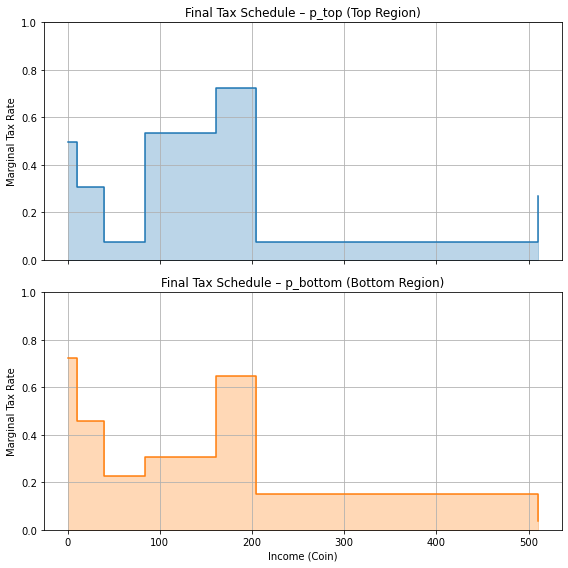

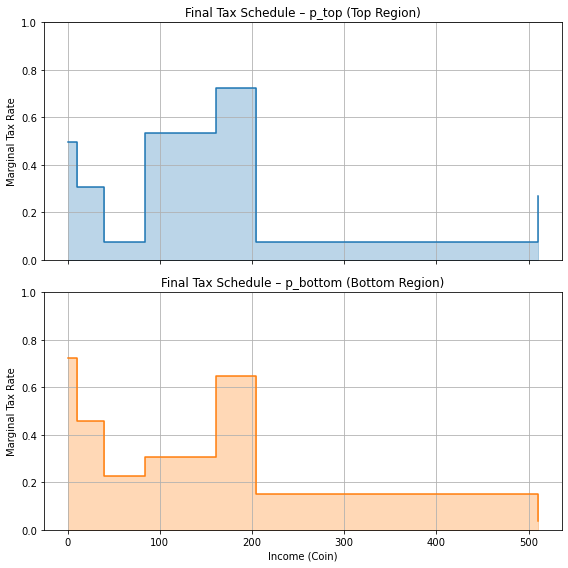

In [67]:
plot_final_tax_schedules_two_planners(dense_logs[0], top_first=True)

In [63]:
for comp in env_obj.env.components:
    if "BracketTax" in comp.name:
        print("=== Component:", comp.name, "===")
        print("rate_min:", comp.rate_min, "rate_max:", comp.rate_max, "rate_disc:", comp.rate_disc)
        print("disc_rates:", comp.disc_rates)
        print("len(disc_rates):", len(comp.disc_rates))
        print("tax_annealing_schedule:", comp.tax_annealing_schedule)
        print("annealed_rate_max:", getattr(comp, "_annealed_rate_max", None))

=== Component: RegionalPeriodicBracketTax ===
rate_min: 0.0 rate_max: 1.0 rate_disc: 0.05
disc_rates: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
len(disc_rates): 21
tax_annealing_schedule: None
annealed_rate_max: 1.0
=== Component: RegionalPeriodicBracketTax ===
rate_min: 0.0 rate_max: 1.0 rate_disc: 0.05
disc_rates: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
len(disc_rates): 21
tax_annealing_schedule: None
annealed_rate_max: 1.0


In [64]:
for comp in env_obj.env.components:
    if "BracketTax" in comp.name:
        if hasattr(comp, "_annealed_rate_max"):
            allowed = comp.disc_rates[comp.disc_rates <= comp._annealed_rate_max]
            print(comp.name, "allowed rate max =", comp._annealed_rate_max,
                  " → allowed choices", allowed, f"(#{len(allowed)})")

RegionalPeriodicBracketTax allowed rate max = 1.0  → allowed choices [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ] (#21)
RegionalPeriodicBracketTax allowed rate max = 1.0  → allowed choices [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ] (#21)


# Phase 1

In [ ]:
env_config_dict.update(
    {
    ("RegionalPeriodicBracketTax", {
    "region": "top",
    "planner_id": "p_top",
    "disable_taxes": True,
    }),
    ("RegionalPeriodicBracketTax", {
        "region": "bottom",
        "planner_id": "p_bottom",
        "disable_taxes": True,
    }),
    }
)




trainer_config.update(
    {
    "multiagent": {
        "policies_to_train": ["agent_policy"],  # <--- ONLY AGENTS TRAIN
    }

    }
)

# phase 2

In [ ]:
("RegionalPeriodicBracketTax", {
    "region": "top",
    "planner_id": "p_top",
    "disable_taxes": False,
    "tax_model": "model_wrapper",
    "tax_annealing_schedule": [-100, 0.001],
}),
("RegionalPeriodicBracketTax", {
    "region": "bottom",
    "planner_id": "p_bottom",
    "disable_taxes": False,
    "tax_model": "model_wrapper",
    "tax_annealing_schedule": [-100, 0.001],
}),

In [ ]:
"policies_to_train": ["p_top_policy", "p_bottom_policy"],